# 🌡️ Optimization of Antipyretic Therapy: Ibuprofen & Paracetamol
## Mathematical Modeling of Body Temperature and Drug Plasma Concentration

---

### 🔍 Problem Definition
Managing high fever requires precise timing. This project addresses a common clinical challenge: **"How can we synchronize the administration of Paracetamol and Ibuprofen to ensure their peak concentrations align with the patient's natural circadian temperature peaks?"**

### 🎯 Research Objectives
1. **Model the Circadian Rhythm:** Create a 24-hour body temperature curve showing fever peaks.
2. **Pharmacokinetic Analysis:** Model the absorption and elimination (Half-life) of Paracetamol and Ibuprofen.
3. **Synergy & Optimization:** Determine the best dosing intervals to maintain the patient within the therapeutic window.
4. **Statistical Evaluation:** Compare the effectiveness of monotherapy vs. combined optimized therapy.

### 🛠️ Mathematical Toolkit
* **Functions:** Defining the temperature curve over time $f(t)$.
* **Derivatives:** Identifying the rate of temperature increase to trigger early intervention.
* **Vectors & Arrays:** Managing concentration data points for both drugs.
* **Integrals (AUC):** Calculating total drug exposure in the system.

---

### 1. Clinical Background: Understanding Body Temperature
Before modeling the data, we must define the physiological parameters of body temperature. According to clinical standards (StatPearls, NCBI):

* **Normal Body Temperature:** Generally considered to be around **37°C (98.6°F)**, though it fluctuates throughout the day.
* **Fever (Pyrexia):** Defined as an elevation in core body temperature above the daily variation. Clinically, a temperature above **38.0°C (100.4°F)** is typically considered a fever.
* **Circadian Rhythm:** Body temperature follows a predictable 24-hour cycle. It is usually lowest in the early morning (c. 04:00) and peaks in the late afternoon/early evening (c. 16:00–20:00).

#### 🧪 Theoretical Case Study
In this project, we utilize a **theoretical temperature profile** to simulate a patient with a moderate fever. This model is based on the physiological principles described in the literature ([NCBI - Fever Spectrum](https://www.ncbi.nlm.nih.gov/books/NBK562334/)). 

We will use this simulated data to demonstrate how mathematical modeling can help optimize the timing of antipyretic administration (Ibuprofen and Paracetamol).

---
### 2. Visualizing the Fever Cycle
The following graph represents our theoretical patient's temperature over a 24-hour period, highlighting the evening peak where intervention becomes most critical.

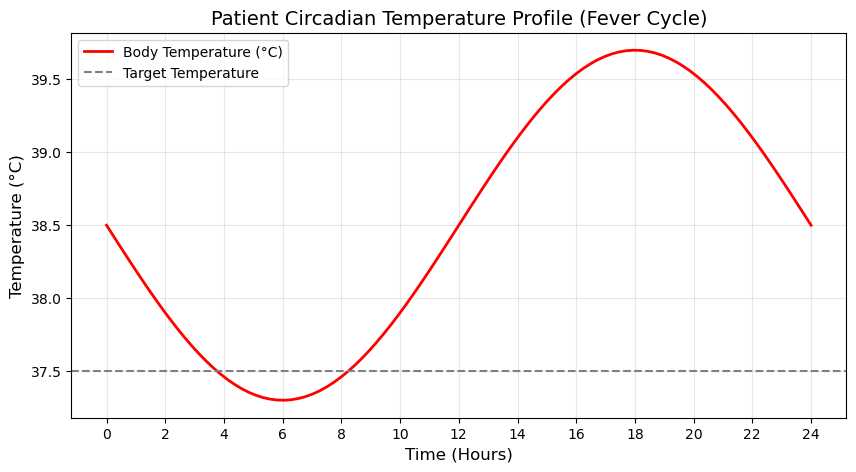

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a Time Vector (from 0 to 24 hours)
# We use 100 points for a smooth curve
time = np.linspace(0, 24, 100)

# 2. Model the Temperature Curve
# Base fever temp is 38.0°C. 
# We add a sine wave to simulate the evening peak (common in fever).
# math: temp(t) = base_temp + amplitude * sin(frequency * t)
temperature = 38.5 + 1.2 * np.sin(2 * np.pi * (time - 12) / 24)

# 3. Plotting the Graph
plt.figure(figsize=(10, 5))
plt.plot(time, temperature, color='red', linewidth=2, label='Body Temperature (°C)')

# Add threshold line (Therapeutic Target < 37.5)
plt.axhline(y=37.5, color='gray', linestyle='--', label='Target Temperature')

# Formatting the graph
plt.title("Patient Circadian Temperature Profile (Fever Cycle)", fontsize=14)
plt.xlabel("Time (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xticks(np.arange(0, 25, 2))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### 5. Paracetamol (Acetaminophen) Pharmacokinetics
To build an accurate mathematical model, we use standard pharmacokinetic parameters for an oral dose of Paracetamol (1000mg for adults).

#### 📊 Key Parameters & Sources:
* **Dose ($D$):** 1000 mg (Standard therapeutic adult dose).
* **Absorption Rate ($k_a$):** Rapid absorption with $T_{max}$ (time to peak concentration) between **0.5 to 1.0 hour**. 
    * *Source: Prescott, L. F. (1980). Kinetics and metabolism of paracetamol and phenacetin. British Journal of Clinical Pharmacology.*
* **Elimination Half-life ($t_{1/2}$):** Approximately **2.5 hours** in healthy individuals. 
    * *Source: Bertolini, A., et al. (2006). Paracetamol: New vistas of an old drug. CNS Drug Reviews.*
* **Elimination Rate Constant ($k_e$):** Calculated as $ln(2) / t_{1/2} \approx 0.277 \, h^{-1}$ (Exponential decay constant).

#### 🧮 The Mathematical Model
We implement a **one-compartment open model** to simulate the drug's journey through the body. The plasma concentration $C(t)$ is modeled using the Bateman function:
$$C(t) = \frac{D \cdot k_a}{V_d(k_a - k_e)} \cdot (e^{-k_e \cdot t} - e^{-k_a \cdot t})$$

---

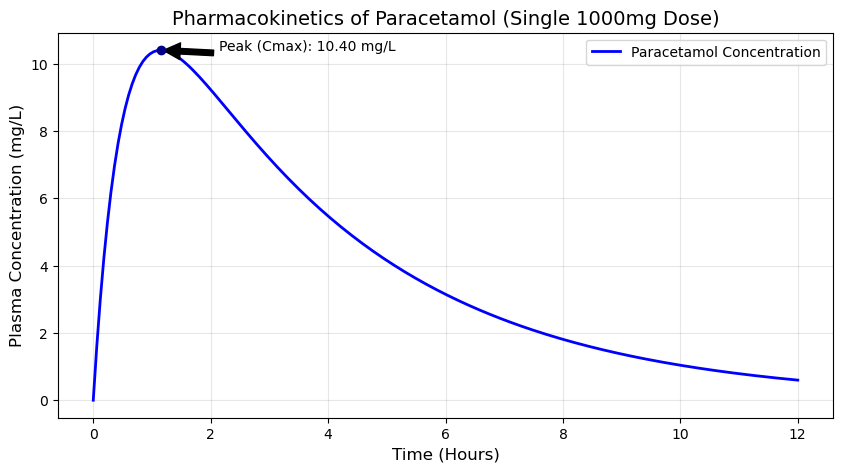

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for Paracetamol (1000mg dose)
D = 1000      # Dose in mg
ka = 2.0      # Absorption rate (fast)
ke = 0.277    # Elimination rate (half-life ~2.5h)
Vd = 70       # Volume of distribution (liters, approx for adult)

# Time vector (0 to 12 hours for detail)
t_p = np.linspace(0, 12, 200)

# One-compartment PK model function
def pk_model(t, D, ka, ke, Vd):
    return (D * ka / (Vd * (ka - ke))) * (np.exp(-ke * t) - np.exp(-ka * t))

conc_p = pk_model(t_p, D, ka, ke, Vd)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_p, conc_p, label='Paracetamol Concentration', color='blue', linewidth=2)

# Marking Tmax and Cmax
t_max_idx = np.argmax(conc_p)
plt.scatter(t_p[t_max_idx], conc_p[t_max_idx], color='darkblue', zorder=5)
plt.annotate(f'Peak (Cmax): {conc_p[t_max_idx]:.2f} mg/L', 
             xy=(t_p[t_max_idx], conc_p[t_max_idx]), xytext=(t_p[t_max_idx]+1, conc_p[t_max_idx]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Pharmacokinetics of Paracetamol (Single 1000mg Dose)", fontsize=14)
plt.xlabel("Time (Hours)", fontsize=12)
plt.ylabel("Plasma Concentration (mg/L)", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()